In [60]:
import numpy as np
import matplotlib.pyplot as plt

import MicroTools as micro
import MicroTools.plot_tools as pt

import MicroTools.param_scan as param_scan
import uproot

In [61]:
from scipy.stats import chi2
levels_sigmas_2dof = [chi2.ppf(0.682689492137086, 2), chi2.ppf(0.954499736103642, 2), chi2.ppf(0.997300203936740, 2), chi2.ppf(0.999936657516334, 2)]
levels_sigmas_3dof = [chi2.ppf(0.682689492137086, 3), chi2.ppf(0.954499736103642, 3), chi2.ppf(0.997300203936740, 3), chi2.ppf(0.999936657516334, 3)]
level_95CL_2dof = [chi2.ppf(0.95, 2)]
level_95CL_3dof = [chi2.ppf(0.95, 3)]
print(level_95CL_2dof)

[np.float64(5.991464547107979)]


In [62]:
def load_scan_data(filename):
    data = param_scan.pickle_read(filename)
    
    data_dic = {}
    data_dic['Ue4SQR'] = data[:,2]
    data_dic['Umu4SQR'] = data[:,3]
    s2t = 4*data_dic['Ue4SQR']*data_dic['Umu4SQR']
    data_dic['sin2theta'] = np.round(s2t, decimals=6)
    data_dic['dm4SQR'] = data[:,1]**2
    
    data_dic['MiniApp_chi2'] =  data[:,-3]
    data_dic['MicroApp_chi2'] =  data[:,-2]
    data_dic['MicroApp_Asimov_chi2'] = data[:,-1] 

    data_dic['MiniApp_deltachi2'] = data_dic['MiniApp_chi2'] - np.min(data_dic['MiniApp_chi2'])
    data_dic['MicroApp_deltachi2'] = data_dic['MicroApp_chi2'] - np.min(data_dic['MicroApp_chi2'])
    data_dic['MicroApp_Asimov_deltachi2'] = data_dic['MicroApp_Asimov_chi2'] - np.min(data_dic['MicroApp_Asimov_chi2'])

    return data_dic


In [63]:
from scipy.interpolate import griddata
def interpolate_data(XX, YY, ZZ, XXI, YYI):
    # XXI and YYI are the grid you want to interpolate onto
    return griddata((XX.flatten(), YY.flatten()), ZZ.flatten(), (XXI, YYI), method='cubic', fill_value=0)

Best fit values and chi2:  [3.39322177 0.42919343 0.01865811]


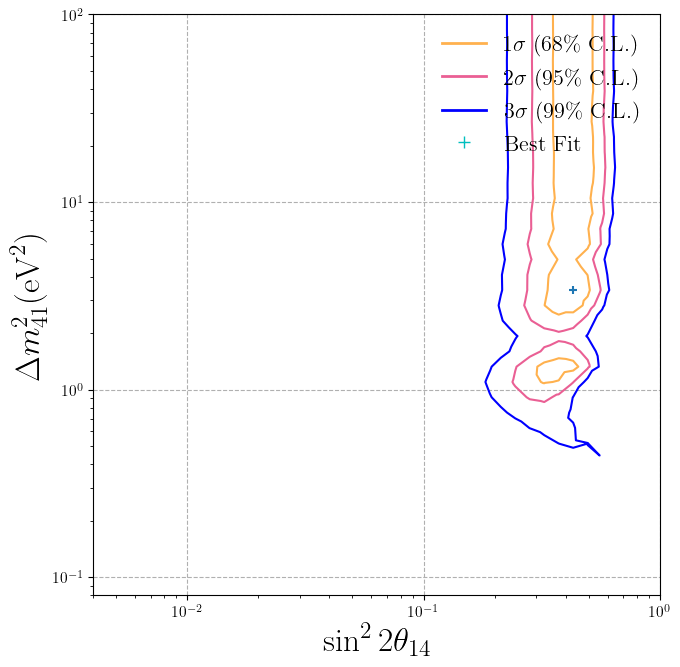

In [83]:
from matplotlib.lines import Line2D
def txt_to_array(filename, sep = ","):
    inputfile = open(filename,'r+')
    file_lines = inputfile.readlines()

    mat = []
    for line in file_lines:
        mat.append(line.strip().split(sep))
    mat = np.array(mat).astype(np.float64)
    return mat

#data_BEST = txt_to_array("BestTools/BestSterileChi2.dat")
data_BEST = np.load("BestTools/BestSterileChi2.npy")
min_index = np.where(data_BEST[:,2] == np.min(data_BEST[:,2]))[0][0]
bestfit_BEST = data_BEST[min_index]
print('Best fit values and chi2: ',bestfit_BEST)

size = (7,7)
margins = dict(left=0.16, right=0.97,bottom=0.1, top=0.93)
color1 = '#FFB14E'
color2 = '#EA5F94'
color3 = '#0000FF'

def stylize(axxis,contours,t_ax = [1e-3,1], m_ax = [1e-2,10]):
    axxis.grid(linestyle = '--')
    axxis.tick_params(axis='x')
    axxis.tick_params(axis='y')
    axxis.set_ylabel(r"$\Delta m^2_{41} (\textrm{eV}^2)$", fontsize = 24)
    axxis.set_xlabel(r"$\sin^2 2 \theta_{14}$", fontsize = 24)
    axxis.set_xlim([4e-3,1])
    axxis.set_ylim([0.08,100.])
    axxis.set_xscale('log')
    axxis.set_yscale('log')
    # labels = [r'$1\sigma$ (68\% C.L.)',r'$2\sigma$ (95\% C.L.)',r'$3\sigma$ (99\% C.L.)']
    # for i in range(3):
    #     contours.collections[i].set_label(labels[i])
    # axxis.legend(loc = 'lower left', fontsize = 20)
    legend_elements = [Line2D([0], [0], color=color1, ls = '-', lw=2, label=r'$1\sigma$ (68\% C.L.)'),
                       Line2D([0], [0], color=color2, ls = '-', lw=2, label=r'$2\sigma$ (95\% C.L.)'),
                       Line2D([0], [0], color=color3, ls = '-', lw=2, label=r'$3\sigma$ (99\% C.L.)'),
                       Line2D([0], [0], marker='+', color='c', lw = 0, label='Best Fit', markerfacecolor='b', markersize=8)]
    axxis.legend(handles = legend_elements, fontsize = 16)

figBF,axBF = plt.subplots(figsize = size,gridspec_kw=margins)

conts = axBF.tricontour(data_BEST[:,1],data_BEST[:,0],(data_BEST[:,2]-bestfit_BEST[2]),levels = [2.30,6.18,11.83],  colors = [color1,color2,color3])
axBF.scatter(bestfit_BEST[1],bestfit_BEST[0],marker = '+', label = r'Best fit')
# axBF.scatter(data_PW[:,1],data_PW[:,0],marker = '+', s = 1.) # This tells us the resolution of our table
stylize(axBF,conts)

figBF.savefig(micro.path_plots+'BEST_contour.png')

[]

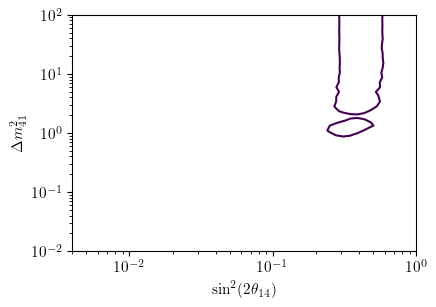

In [84]:
data_dic = load_scan_data('fit_data/fits_before_May6/MH_numu_MC_keep_numu_norm.pkl')
y_int = np.unique(data_dic['dm4SQR'])
Ue4SQR = np.unique(data_dic['Ue4SQR'])
Um4SQR = np.unique(data_dic['Umu4SQR'])
x_int = 4*Ue4SQR*(1-Ue4SQR)
x_int, y_int = np.meshgrid(x_int, y_int)
x, y, z = data_BEST[:,1], data_BEST[:,0], data_BEST[:,2]-bestfit_BEST[2]
z_int = interpolate_data(x, y, z, x_int, y_int)
plt.contour(x_int, y_int, z_int, levels=level_95CL_2dof)
plt.xlabel(r'$\sin^2(2\theta_{14})$')
plt.ylabel(r'$\Delta m^2_{41}$')
#plt.xlim(4e-3, 1)
#plt.ylim(8e-2, 100)
plt.loglog()

In [94]:
# Add BEST chi2 to data_dic
data_dic = load_scan_data('fit_data/fits_before_May6/MH_numu_MC_keep_numu_norm.pkl')
x, y, z = data_BEST[:,1], data_BEST[:,0], data_BEST[:,2]
data_dic['BEST_chi2'] = interpolate_data(x, y, z, 4*data_dic['Ue4SQR']*(1 - data_dic['Ue4SQR']), data_dic['dm4SQR'])
print(data_dic['BEST_chi2'].shape)
data_dic['BEST_deltachi2'] = data_dic['BEST_chi2'] - np.nanmin(data_dic['BEST_chi2'])

(124950,)


In [85]:
y_int = np.unique(data_dic['dm4SQR'])
Ue4SQR = np.unique(data_dic['Ue4SQR'])
# delete the last element to match the dimension of chi2
Ue4SQR = Ue4SQR[:-1]
Um4SQR = np.unique(data_dic['Umu4SQR'])
x_int = 4*Ue4SQR*(1-Ue4SQR)
x_int, y_int = np.meshgrid(x_int, y_int)
x, y, z = data_BEST[:,1], data_BEST[:,0], data_BEST[:,2]-bestfit_BEST[2]
z_int_2450 = interpolate_data(x, y, z, x_int, y_int)

In [86]:
BEST_chi2_nan = z_int.T.flatten()
BEST_chi2 = np.nan_to_num(BEST_chi2_nan, nan=0)

BEST_chi2_2450_nan = z_int_2450.T.flatten()
BEST_chi2_2450 = np.nan_to_num(BEST_chi2_2450_nan, nan=0)
print(BEST_chi2.shape)
print(BEST_chi2_2450.shape)
def choose_BEST_chi2(i):
    if i == 8:
        return BEST_chi2_2450
    return BEST_chi2

(2500,)
(2450,)


In [100]:
labels_slices = [r'$g_\varphi$',r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]
string_slices = [r'$g_\varphi$',r'$\Delta m_{41}^2$', r"$|U_{e 4}|^2$", r"$|U_{\mu 4}|^2$", r"$\sin^2(2\theta_{\mu e})$"]
def get_var(data, i):
    if i == 1:
        return data[:,1]**2
    return data[:,i]

def plot_all_slices(filename, xi=2, yi=3, zi=1, global_deltachi2=False):
    data = param_scan.pickle_read(f"fit_data/fits_before_May6/{filename}.pkl")   
    
    MiniApp_chi2, MicroApp_chi2, MicroApp_Asimov_chi2 = data[:,-3], data[:,-2], data[:,-1] 
    MiniApp_deltachi2 = MiniApp_chi2 - np.min(MiniApp_chi2)
    MicroApp_deltachi2 = MicroApp_chi2 - np.min(MicroApp_chi2)
    MicroApp_Asimov_deltachi2 = MicroApp_Asimov_chi2 - np.min(MicroApp_Asimov_chi2)
    BEST_delta_chi2 = data_dic['BEST_deltachi2']

    x, y, z = get_var(data,xi), get_var(data,yi), get_var(data,zi)
    i_min = np.argmin(MiniApp_deltachi2)
    x_min, y_min, z_min = x[i_min], y[i_min], z[i_min]
    
    # make sure global best-fit is in one of the slices
    z_slices = np.geomspace(np.min(z), np.max(z),9,endpoint=True)
    if z_min not in z_slices:
        z_slices = np.delete(z_slices, np.argmin(np.abs(z_slices - z_min)))
        z_slices = np.append(z_slices, z_min)
    z_slices = np.sort(z_slices)
    
    fig, axs = plt.subplots(3, 3, figsize=(8, 8), sharex=False, sharey=False, constrained_layout=False)
    plt.subplots_adjust(hspace=0.075, wspace=0.05)
    axs = axs.flatten()
    for i, z_slice in enumerate(z_slices):
        # find the closest slice to the true value
        z_slice_true = z[np.argmin(np.abs(z - z_slice))]
        cut = (z == z_slice_true)


        ax = axs[i]
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(axis="both", which='both', direction="inout", left="off", labelleft="on", zorder=10,labelsize=13)

        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(y.min(), y.max())

        # delete the last element in Ue4SQR when Um4SQR = 0.5

        if i in [0,3,6]:
            ax.set_ylabel(string_slices[yi], fontproperties=pt.font, fontsize=13)
        else:
            ax.set_yticklabels([])
            
        if i in [6,7,8]:
            ax.set_xlabel(string_slices[xi], fontproperties=pt.font, fontsize=13)
        else:
            ax.set_xticklabels([])

        ax.annotate(text=fr"{string_slices[zi]} $\,= {z_slice_true:.3f}$", 
                    xycoords='axes fraction', 
                    xy=(0.05,0.86), 
                    fontsize=13, 
                    bbox=dict(facecolor='white', edgecolor='None', alpha=0.9, boxstyle='round'))

        kwargs_interp = {   'fine_gridx': len(np.unique(x)),  
                            'fine_gridy': len(np.unique(y)), 
                            'logx':True, 
                            'logy':True,
                            'method': 'triangulation'
                        }
        #print(MiniApp_chi2[cut].shape)

        if global_deltachi2:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], BEST_delta_chi2[cut], **kwargs_interp)
            MB_levels = level_95CL_3dof
        else:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], BEST_delta_chi2[cut], **kwargs_interp)
            MB_levels = level_95CL_2dof
        cs = ax.contour(X,Y,Z, levels=MB_levels, colors=['grey'], zorder=2)

        if global_deltachi2:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MiniApp_chi2[cut]-np.min(MiniApp_chi2), **kwargs_interp)
            MB_levels = levels_sigmas_3dof
        else:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MiniApp_chi2[cut]-np.min(MiniApp_chi2[cut]), **kwargs_interp)
            MB_levels = levels_sigmas_2dof
        
        cs = ax.contourf(X,Y,Z, levels=[0]+MB_levels, colors=['tomato','darkorange','orange','peachpuff'], zorder=1, alpha=0.75)
        cs = ax.contour(X,Y,Z, levels=MB_levels, colors=['black','black','black','black'], linewidths=0.25, zorder=1, alpha=0.75)
        ax.scatter(X.flatten()[np.argmin(Z)], Y.flatten()[np.argmin(Z)], marker='*', facecolor='white', edgecolor='black', lw=0.5, zorder=10)

        if global_deltachi2:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2)+BEST_delta_chi2[cut], **kwargs_interp)
            level_MicroBooNE = level_95CL_3dof
        else:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_chi2[cut] - np.min(MicroApp_chi2[cut])+BEST_delta_chi2[cut], **kwargs_interp)
            level_MicroBooNE = level_95CL_2dof
        cs = ax.contour(X,Y,Z, levels=level_MicroBooNE, colors=['black'], zorder=2)

        if global_deltachi2:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_Asimov_chi2[cut] - np.min(MicroApp_Asimov_chi2)+BEST_delta_chi2[cut], **kwargs_interp)
        else:
            X, Y, Z = pt.interp_grid(x[cut], y[cut], MicroApp_Asimov_chi2[cut] - np.min(MicroApp_Asimov_chi2[cut])+BEST_delta_chi2[cut], **kwargs_interp)
        cs = ax.contour(X,Y,Z, levels=level_MicroBooNE, colors=['black'], linestyles=[(1,(3,1))], zorder=2)
        if z_min == z_slice:
            ax.scatter(x_min, y_min, marker='*', facecolor='black', edgecolor='black', lw=0.25, zorder=10)
        if i == 0:
            ax.fill([], [], edgecolor='black', facecolor='darkorange', lw=0.25, label='MB ($1 \sigma$)')
            ax.fill([], [], edgecolor='black', facecolor='orange', lw=0.25, label='MB ($2 \sigma$)')
            ax.fill([], [], edgecolor='black', facecolor='peachpuff', lw=0.25, label='MB ($3 \sigma$)')
            ax.plot([], [], color='black', lw=1.5, label='$\mu$B 95\% CL')
            ax.plot([], [], color='black', lw=1.5, ls='--', label='$\mu$B (Asimov) 95\% CL')
            ax.plot([], [], color='grey', lw=1.5, label='BEST 95\% CL')
            ax.legend(loc=(0,0), fontsize=9)
    
    # ndof = r' $\vert$ $n_{\rm dof} = 2$' if global_deltachi2 else r' $\vert$ $n_{\rm dof} = 2$'
    fig.savefig(f"{micro.path_plots}/Micro+BEST_slices{'_global' if global_deltachi2 else ''}.pdf", bbox_inches='tight', dpi=300)



(2500,)
(2500,)
(2500,)
(2500,)
(2500,)
(2500,)
(2500,)
(2500,)
(2450,)


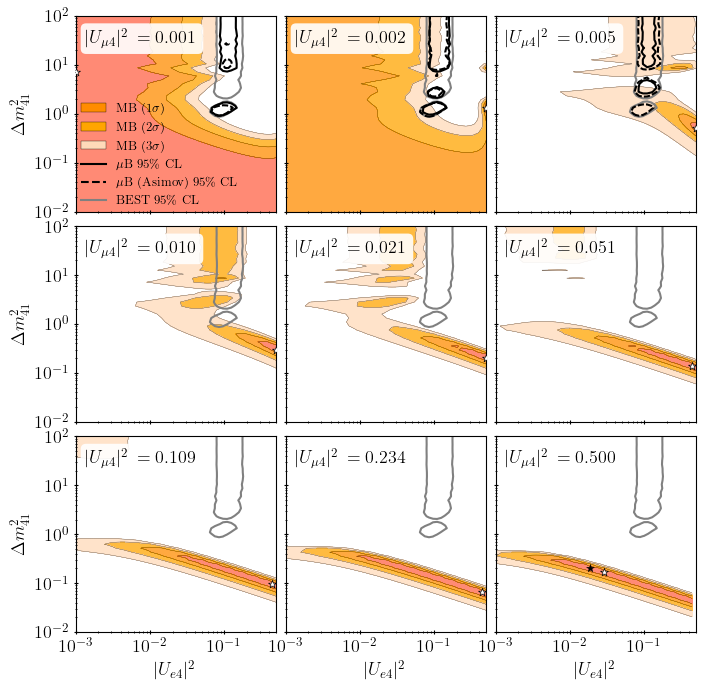

In [98]:
plot_all_slices('MH_numu_MC_keep_numu_norm', xi=2, yi=1, zi=3, global_deltachi2=False)

(2499,)
(2499,)
(2499,)
(2499,)
(2499,)
(2499,)
(2499,)
(2499,)
(2499,)


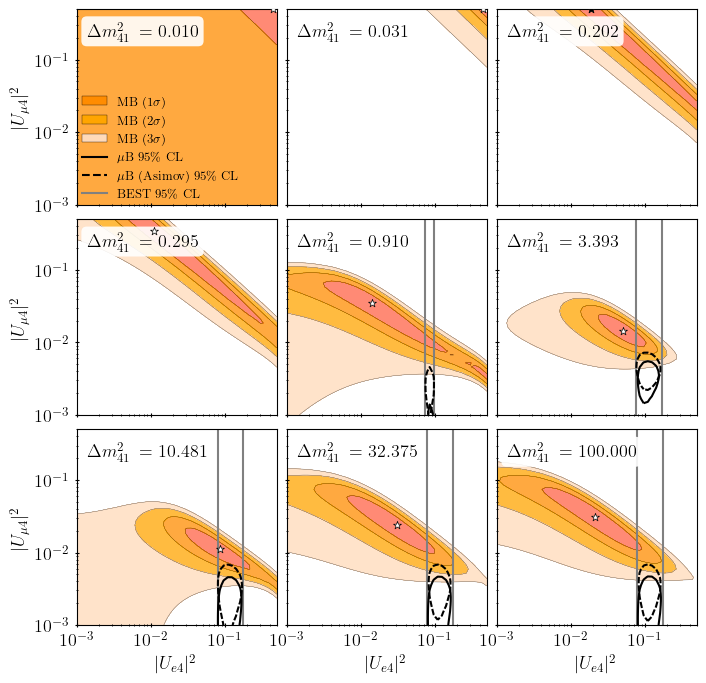

In [99]:
plot_all_slices('MH_numu_MC_keep_numu_norm', xi=2, yi=3, zi=1, global_deltachi2=False)

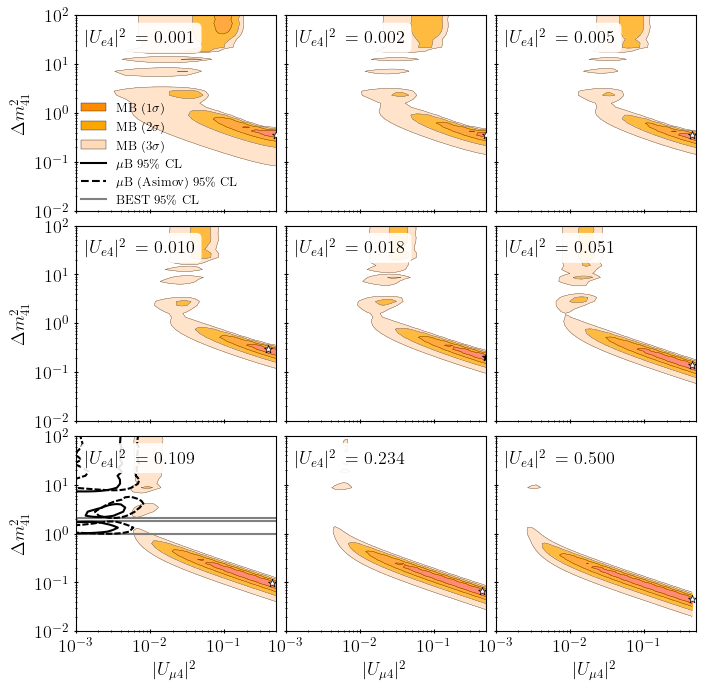

In [101]:
plot_all_slices('MH_numu_MC_keep_numu_norm', xi=3, yi=1, zi=2, global_deltachi2=False)

## Profiled plot.
Some variables are redefined. So be careful.

In [89]:
def make_sin2thetaemu_plot(ax1, dic, name='default', asimov=False, cmap_color='steelblue', n_sigmas=4, cmin=0.05, cmax=0.95,):
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel(r"$\sin^2(2\theta_{\mu e})$", fontproperties=pt.font)
    ax1.set_ylabel(r'$\Delta m_{41}^2 [\mathrm{eV^2}]$', fontproperties=pt.font)
    ax1.set_title(fr"profiled -- " + name.replace('_',' '), fontsize=10)
    # ax1.set_xlim(1e-4,0.2)

    kwargs_interp = {'fine_gridx': len(np.unique(dic['sin2theta'])),  
                    'fine_gridy': len(np.unique(dic['dm4SQR'])), 
                    'logx':True, 
                    'logy':True}
    # X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MiniApp_deltachi2'], **kwargs_interp)
    # cs = ax1.contourf(X,Y,Z, levels=[0, 2.3, 6.18, 11.83, 19.33], colors=['tomato','darkorange','orange','peachpuff'], zorder=1, alpha=0.75)
    # cs = ax1.contour(X,Y,Z, levels=[2.3, 6.18, 11.83, 19.33], colors=['black','black','black','black'], linewidths=0.25, zorder=1, alpha=0.75)
    # # ax1.scatter(app_dic['sin2theta'], app_dic['dm4SQR'])
    
    colors = pt.get_cmap_colors(cmap_color, n_sigmas, cmin=cmin, cmax=cmax)
    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MiniApp_deltachi2'], **kwargs_interp)
    cs = ax1.contourf(X,Y,Z, levels=pt.get_chi2vals_w_nsigmas(n_sigmas, 2), colors=colors, zorder=1, alpha=1)
    cs = ax1.contour(X,Y,Z, levels=pt.get_chi2vals_w_nsigmas(n_sigmas, 2), colors=['black'], linewidths=0.25, zorder=1, alpha=1)
    # ax1.scatter(dic['Umu4SQR'], dic['dm4SQR'], c=np.log10(dic['MiniApp_chi2']-np.min(dic['MiniApp_chi2'])),)
    ax1.scatter(X.flatten()[np.nanargmin(Z)], Y.flatten()[np.nanargmin(Z)], marker='*', facecolor='black', edgecolor='black', lw=0.5, zorder=10)

    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MicroApp_deltachi2'], **kwargs_interp)
    cs = ax1.contour(X,Y,Z, levels=[5.99], colors=['black'], linewidths=[1], linestyles=[(1,(3,0.5))],zorder=2)

    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['BEST_deltachi2'], **kwargs_interp)
    cs = ax1.contour(X,Y,Z, levels=[5.99], colors=['black'], linewidths=[1], linestyles=[(1,(1,1))], zorder=2)
    
    X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MicroBEST_deltachi2'], **kwargs_interp)
    cs = ax1.contour(X,Y,Z, levels=[5.99], colors=['black'], zorder=2)
    
    if asimov:
        X, Y, Z = pt.interp_grid(dic['sin2theta'], dic['dm4SQR'], dic['MicroApp_Asimov_deltachi2'], **kwargs_interp)
        cs = ax1.contour(X,Y,Z, levels=[5.99], colors=['black'], linestyles=[(1,(3,1))], zorder=2)

    ax1.plot([], [], color='black', lw=1.5, label='$\mu$B+BEST')
    ax1.plot([], [], color='black', lw=1., ls=(1,(1,1)), label='BEST')
    ax1.plot([], [], color='black', lw=1., ls=(1,(3,0.5)), label='$\mu$B')
    if asimov:
        ax1.plot([], [], color='black', lw=1.5, ls='--', label='$\mu$B (Asimov)')


    x,y=np.genfromtxt('MicroTools/muB_data/official/official_contour.dat', unpack=True)
    l1=ax1.plot(x,y, ls='-', color='red', label=r'$\mu$B 2022 (BNB)')
    x,y=np.genfromtxt('MicroTools/muB_data/official/BNB_and_NUMI_sensitivity.dat', unpack=True)
    l3=ax1.plot(x,y, ls=(1,(1,1)), lw=1.5, color='red', label=r'$\mu$B 2022 (BNB+NuMI) sens')
    x,y=np.genfromtxt('MicroTools/muB_data/official/app_only_2022_official.dat', unpack=True)
    l2=ax1.plot(x,y, ls=(1,(1,0.5)), lw=1, color='red', label=r'$\mu$B 2022 (BNB app-only)')
    
    # ------ get the legend-entries that are already attached to the axis
    h, l = ax1.get_legend_handles_labels()
    mb_label = 'MB '+', '.join([fr'${i+1} \sigma$' for i in range(n_sigmas)])
    leg1 = ax1.legend([pt.MulticolorPatch(colors)], [mb_label], loc='upper right', fontsize=9, handler_map={pt.MulticolorPatch: pt.MulticolorPatchHandler()})
    ax1.add_artist(leg1)
    leg2 = ax1.legend(h, l, loc=(0,0), fontsize=7, ncol=2, handler_map={pt.MulticolorPatch: pt.MulticolorPatchHandler()}, title='Regions at $95\%$ CL', title_fontsize=8)
    leg2._legend_box.align = "left"
    # ax1.add_artist(leg2)

    return ax1
    # fig.savefig(f"{micro.path_plots}/MH_full_osc_sin2thetaemuSQR_profiled.pdf", bbox_inches='tight', dpi=300)
    # fig.savefig(f"{micro.path_plots}/MH_full_osc_sin2thetaemuSQR_profiled_{name}.pdf", bbox_inches='tight', dpi=300)



In [90]:
def profile_for_sin2theta(data_dic, **kwargs):
    dic_prof = {}
    # Profile each chi2
    dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MiniApp_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MiniApp_deltachi2'], **kwargs)
    dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MicroApp_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MicroApp_deltachi2'], **kwargs)
    dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MicroApp_Asimov_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MicroApp_Asimov_deltachi2'], **kwargs)
    if 'PROS_deltachi2' in data_dic.keys():
        dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['PROS_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['PROS_deltachi2'], **kwargs)
    if 'MicroPROS_deltachi2' in data_dic.keys():
        dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MicroPROS_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MicroPROS_deltachi2'], **kwargs)
    if 'BEST_deltachi2' in data_dic.keys():
        dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['BEST_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['BEST_deltachi2'], **kwargs)
    if 'MicroBEST_deltachi2' in data_dic.keys():
        dic_prof['sin2theta'], dic_prof['dm4SQR'], dic_prof['MicroBEST_deltachi2'] = param_scan.profile_in_plane(data_dic['sin2theta'], data_dic['dm4SQR'], data_dic['MicroBEST_deltachi2'], **kwargs)
    return dic_prof

In [91]:
y_int = np.unique(data_dic['dm4SQR'])
Ue4SQR = np.unique(data_dic['Ue4SQR'])
Um4SQR = np.unique(data_dic['Umu4SQR'])
x_int = 4*Ue4SQR*(1-Ue4SQR)
x_int, y_int = np.meshgrid(x_int, y_int)
x, y, z = data_BEST[:,1], data_BEST[:,0], data_BEST[:,2]
data_dic['BEST_chi2'] = interpolate_data(x, y, z, 4*data_dic['Ue4SQR']*(1 - data_dic['Ue4SQR']), data_dic['dm4SQR'])

data_dic['BEST_deltachi2'] = data_dic['BEST_chi2'] - np.nanmin(data_dic['BEST_chi2'])

data_dic['MicroBEST_chi2'] = data_dic['BEST_chi2'] + data_dic['MicroApp_chi2']
data_dic['MicroBEST_deltachi2'] = data_dic['MicroBEST_chi2'] - np.nanmin(data_dic['MicroBEST_chi2'])
# Profile to get sin2theta_emu
# kwargs = {"profile_over_diff_chi2": data_dic['MiniApp_deltachi2']}
kwargs={}
profiled_dic = profile_for_sin2theta(data_dic, **kwargs)

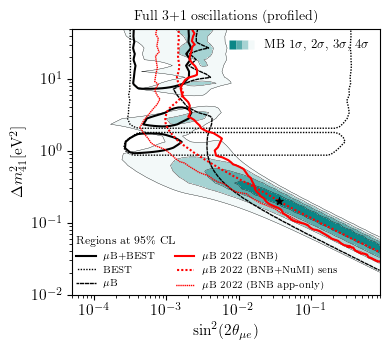

In [92]:
f = [0.18, 0.16, 0.77, 0.76]
fig, ax = pt.std_fig(figsize=(4, 3.5), ax_form=f)
# fig, ax = make_sin2thetaemu_plot_comparison(dic_numu_MC_keep_numu_norm, name='numu_MC_keep_numu_norm')

ax = make_sin2thetaemu_plot(ax, profiled_dic, name='numu_MC_keep_numu_norm', asimov=False, cmap_color='teal')
# x,y=np.genfromtxt('MiniTools/include/MB_data_release_2022/miniboone_fit_3sigma_1.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,1)))

# x,y=np.genfromtxt('MiniTools/include/MB_data_release_2022/miniboone_fit_3sigma_2.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,1)), label=r'MB coll. - $3\sigma$')


# x,y=np.genfromtxt('MiniTools/include/MB_data_release_2022/miniboone_fit_4sigma_1.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,0)))

# x,y=np.genfromtxt('MiniTools/include/MB_data_release_2022/miniboone_fit_4sigma_2.dat', unpack=True)
# x,y=pt.get_ordered_closed_region([x,y], logx=True, logy=True)
# ax.plot(x,y, color='black', ls=(1,(3,0)), label=r'MB coll. - $4\sigma$')

ax.set_xlim(0.5e-4,0.9)
ax.set_ylim(1e-2,50)
ax.set_title(r'Full 3+1 oscillations (profiled)', fontsize=10)
fig.savefig(f"{micro.path_plots}/fullosc_BEST_micro.pdf", dpi=300)

In [81]:
#combine 3 numpy file into one
data1 = np.load('BestTools/PWSterileMass.npy')
data2 = np.load('BestTools/PWSterileAngle.npy')
data3 = np.load('BestTools/PWSterileChi2.npy')
data = np.column_stack((data1,data2,data3))
np.save('BestTools/BestSterileChi2.npy',data)

In [82]:
print(data1)

[1.e-02 1.e-02 1.e-02 ... 1.e+02 1.e+02 1.e+02]
